In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
output_folder = 'output/synthetic'
baselines = ['NEG_DSD', 'DCSGreedy', 'CEP']
simulators = ['BA', 'ER', 'RGG', 'SBM', 'WS']

In [3]:
def load_results(output_folder, baselines, simulators):
    """
    Load all results from the output folder structure.
    Returns a pandas DataFrame with columns:
    [simulator, graph_params, setting, instance, baseline, density, time]
    """
    results = []
    
    for simulator in simulators:
        simulator_path = os.path.join(output_folder, simulator)
        if not os.path.exists(simulator_path):
            continue
            
        # Iterate through graph folders
        for graph_folder in os.listdir(simulator_path):
            graph_path = os.path.join(simulator_path, graph_folder)
            if not os.path.isdir(graph_path):
                continue
            
            # Look for JSON files in this folder
            for baseline in baselines:
                file_name = f"{graph_folder}_{baseline}.json"
                # Load JSON and extract metrics
                json_path = os.path.join(graph_path, file_name)
                try:
                    with open(json_path, 'r') as f:
                        data = json.load(f)
                    
                    results.append({
                        'simulator': simulator,
                        'graph_folder': graph_folder,
                        'baseline': baseline,
                        'density': data.get('density'),
                        'time': data.get('time')
                    })
                except Exception as e:
                    print(f"Error loading {json_path}: {e}")

    return pd.DataFrame(results)

# Load all data
df = load_results(output_folder, baselines, simulators)

Error loading output/synthetic/BA/BA_n500000_m2_setting64_inst0/BA_n500000_m2_setting64_inst0_CEP.json: [Errno 2] No such file or directory: 'output/synthetic/BA/BA_n500000_m2_setting64_inst0/BA_n500000_m2_setting64_inst0_CEP.json'


/tmp/ipykernel_68291/3993176176.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[idx].boxplot([sim_data[sim_data['baseline'] == b]['density'].dropna()
/tmp/ipykernel_68291/3993176176.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[idx].boxplot([sim_data[sim_data['baseline'] == b]['density'].dropna()
/tmp/ipykernel_68291/3993176176.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[idx].boxplot([sim_data[sim_data['baseline'] == b]['density'].dropna()
/tmp/ipykernel_68291/3993176176.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Mat

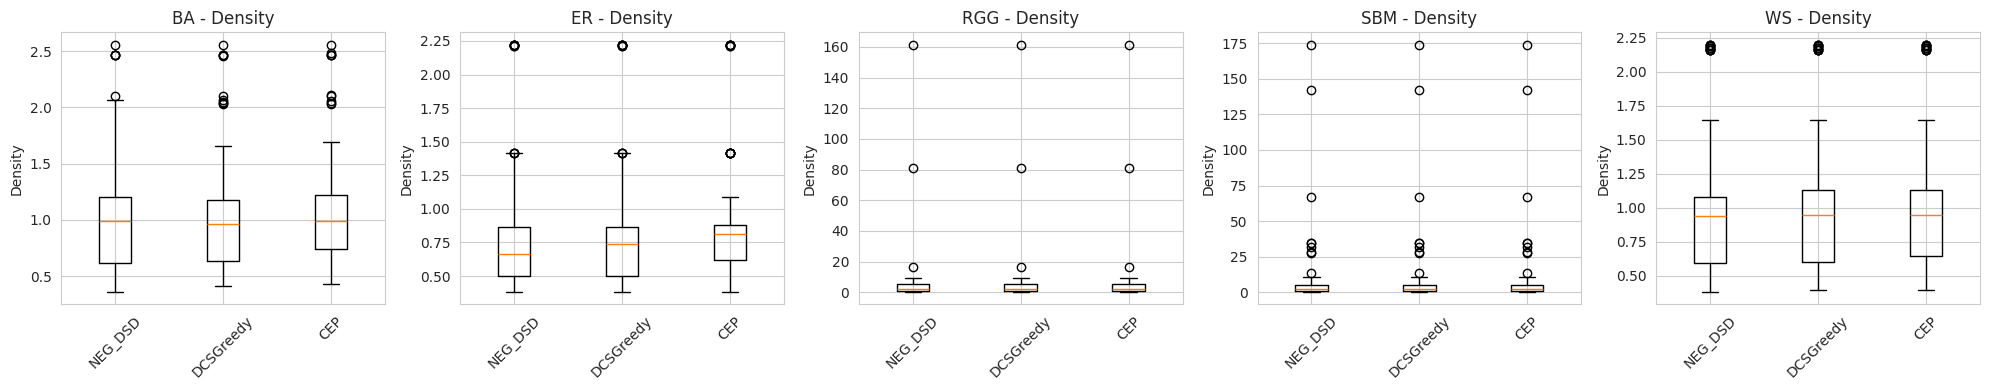

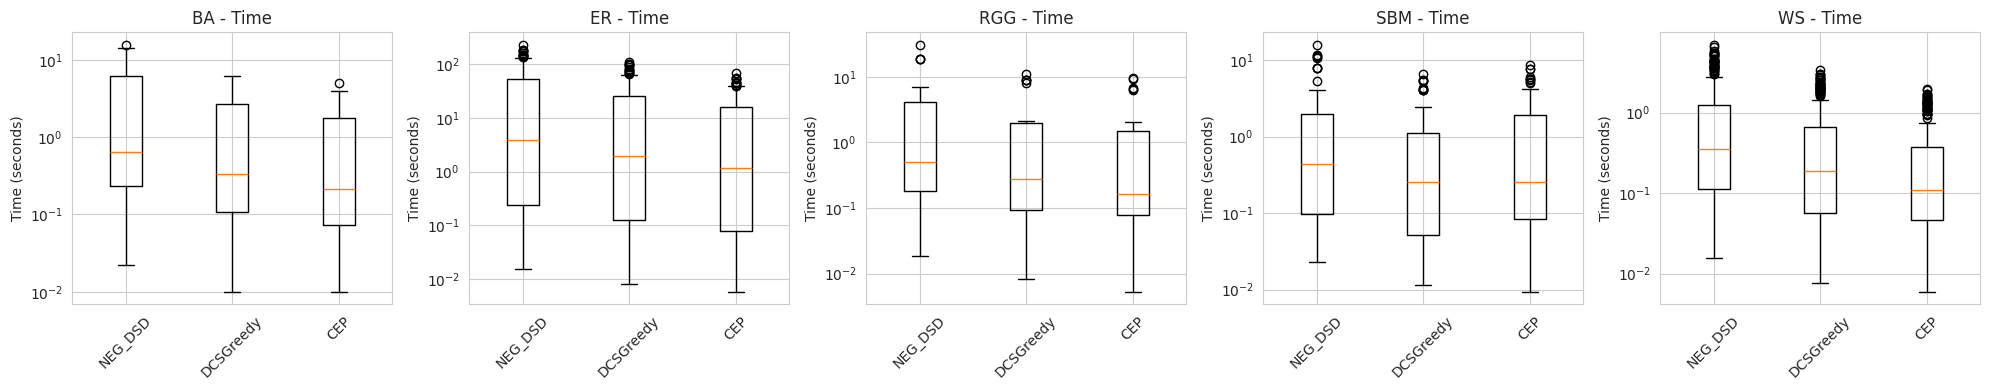

In [5]:
def draw_boxplots(simulators):
    # Set style
    sns.set_style('whitegrid')

    num_sim = len(simulators)

    # 1. Density comparison across simulators
    fig, axes = plt.subplots(1, num_sim, figsize=(4*num_sim, 4))
    for idx, simulator in enumerate(simulators):
        sim_data = df[df['simulator'] == simulator]
        axes[idx].boxplot([sim_data[sim_data['baseline'] == b]['density'].dropna() 
                        for b in sim_data['baseline'].unique()],
                        labels=sim_data['baseline'].unique())
        axes[idx].set_title(f'{simulator} - Density')
        axes[idx].set_ylabel('Density')
        axes[idx].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    # plt.savefig('density_comparison.png', dpi=300, bbox_inches='tight')

    # 2. Time comparison (log scale recommended)
    fig, axes = plt.subplots(1, num_sim, figsize=(4*num_sim, 4))
    for idx, simulator in enumerate(simulators):
        sim_data = df[df['simulator'] == simulator]
        axes[idx].boxplot([sim_data[sim_data['baseline'] == b]['time'].dropna() 
                        for b in sim_data['baseline'].unique()],
                        labels=sim_data['baseline'].unique())
        axes[idx].set_title(f'{simulator} - Time')
        axes[idx].set_ylabel('Time (seconds)')
        axes[idx].set_yscale('log')
        axes[idx].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    # plt.savefig('time_comparison.png', dpi=300, bbox_inches='tight')

draw_boxplots(simulators)

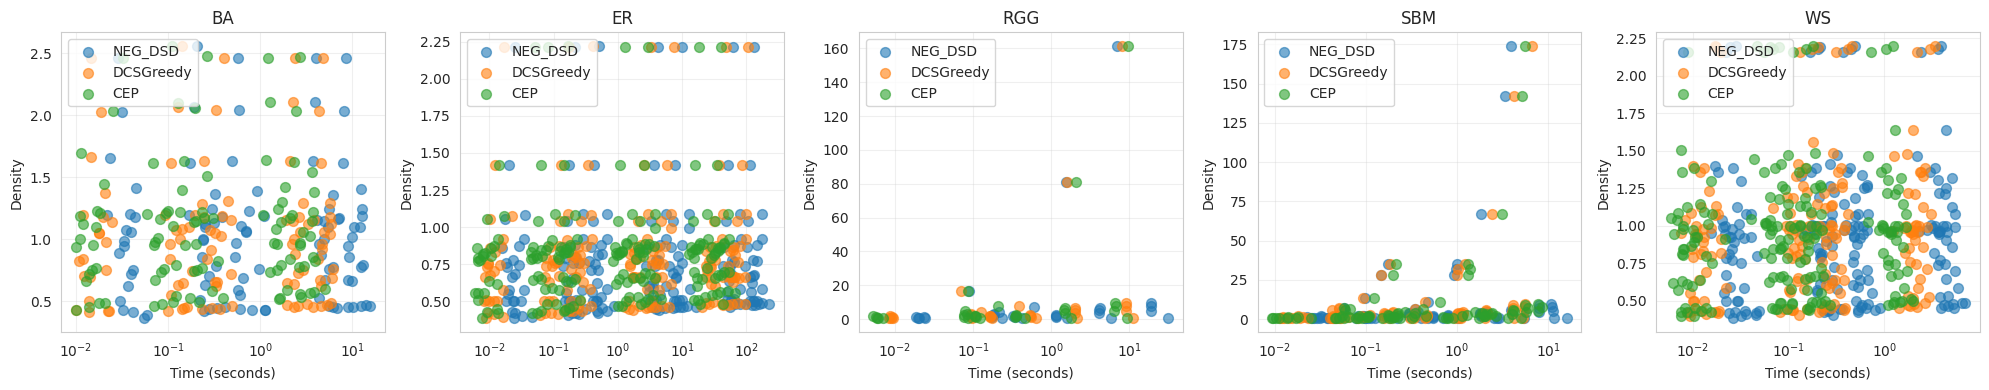

In [6]:
def draw_pareto(simulators):
    # For each simulator, plot density vs time
    fig, axes = plt.subplots(1, len(simulators), figsize=(4*len(simulators), 4))
    for idx, simulator in enumerate(simulators):
        sim_data = df[df['simulator'] == simulator]
        
        for baseline in sim_data['baseline'].unique():
            baseline_data = sim_data[sim_data['baseline'] == baseline]
            axes[idx].scatter(baseline_data['time'], baseline_data['density'], 
                            label=baseline, alpha=0.6, s=50)
        
        axes[idx].set_xlabel('Time (seconds)')
        axes[idx].set_ylabel('Density')
        axes[idx].set_title(f'{simulator}')
        axes[idx].set_xscale('log')
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('pareto_comparison.png', dpi=300, bbox_inches='tight')

draw_pareto(simulators)

In [7]:
def compute_rankings():
    # For each graph, rank baselines by density (higher is better) and time (lower is better)
    df['density_rank'] = df.groupby('graph_folder')['density'].rank(ascending=False)
    df['time_rank'] = df.groupby('graph_folder')['time'].rank(ascending=True)

    # Average rank per baseline per simulator
    rank_summary = df.groupby(['simulator', 'baseline'])[['density_rank', 'time_rank']].mean()
    print("\nAverage Rankings (lower is better):")
    print(rank_summary)

compute_rankings()


Average Rankings (lower is better):
                     density_rank  time_rank
simulator baseline                          
BA        CEP            1.190000   1.060000
          DCSGreedy      2.645000   1.950000
          NEG_DSD        2.165000   2.990000
ER        CEP            1.442857   1.022857
          DCSGreedy      2.202857   1.982857
          NEG_DSD        2.354286   2.994286
RGG       CEP            1.600000   1.166667
          DCSGreedy      2.150000   1.966667
          NEG_DSD        2.250000   2.866667
SBM       CEP            1.775000   2.112500
          DCSGreedy      2.262500   1.362500
          NEG_DSD        1.962500   2.525000
WS        CEP            1.719444   1.038889
          DCSGreedy      2.047222   1.972222
          NEG_DSD        2.233333   2.988889


In [8]:
def pairwise_comparison(df, simulator, metric='density'):
    """Perform pairwise Wilcoxon signed-rank tests"""
    sim_data = df[df['simulator'] == simulator]
    baselines = sim_data['baseline'].unique()
    
    print(f"\n{simulator} - {metric.upper()} Pairwise Comparisons:")
    for i, b1 in enumerate(baselines):
        for b2 in baselines[i+1:]:
            data1 = sim_data[sim_data['baseline'] == b1][metric].dropna()
            data2 = sim_data[sim_data['baseline'] == b2][metric].dropna()
            
            # Only compare if we have matching instances
            if len(data1) > 0 and len(data2) > 0:
                stat, p_value = stats.wilcoxon(data1, data2)
                print(f"{b1} vs {b2}: p-value = {p_value:.6f}")

# Run for each simulator
for sim in simulators:
    pairwise_comparison(df, sim, 'density')
    pairwise_comparison(df, sim, 'time')


BA - DENSITY Pairwise Comparisons:
NEG_DSD vs DCSGreedy: p-value = 0.000027
NEG_DSD vs CEP: p-value = 0.000000
DCSGreedy vs CEP: p-value = 0.000000

BA - TIME Pairwise Comparisons:
NEG_DSD vs DCSGreedy: p-value = 0.000000
NEG_DSD vs CEP: p-value = 0.000000
DCSGreedy vs CEP: p-value = 0.000000

ER - DENSITY Pairwise Comparisons:
NEG_DSD vs DCSGreedy: p-value = 0.000000
NEG_DSD vs CEP: p-value = 0.000000
DCSGreedy vs CEP: p-value = 0.000000

ER - TIME Pairwise Comparisons:
NEG_DSD vs DCSGreedy: p-value = 0.000000
NEG_DSD vs CEP: p-value = 0.000000
DCSGreedy vs CEP: p-value = 0.000000

RGG - DENSITY Pairwise Comparisons:
NEG_DSD vs DCSGreedy: p-value = 0.530285
NEG_DSD vs CEP: p-value = 0.000724
DCSGreedy vs CEP: p-value = 0.001116

RGG - TIME Pairwise Comparisons:
NEG_DSD vs DCSGreedy: p-value = 0.000001
NEG_DSD vs CEP: p-value = 0.000014
DCSGreedy vs CEP: p-value = 0.000123

SBM - DENSITY Pairwise Comparisons:
NEG_DSD vs DCSGreedy: p-value = 0.862263
NEG_DSD vs CEP: p-value = 0.000639


In [9]:
from scipy.stats import wilcoxon

In [10]:
def pairwise_comparison(df, simulator, metric='density'):
    """Perform pairwise Wilcoxon signed-rank tests on paired (graph_folder) samples"""
    sim_data = df[df['simulator'] == simulator]
    baselines = sim_data['baseline'].unique()

    print(f"\n{simulator} - {metric.upper()} Pairwise Comparisons:")
    results = []

    for i, b1 in enumerate(baselines):
        for b2 in baselines[i+1:]:
            # 合并不同 baseline 的数据，保证对齐同一 graph_folder
            df1 = sim_data[sim_data['baseline'] == b1][['graph_folder', metric]]
            df2 = sim_data[sim_data['baseline'] == b2][['graph_folder', metric]]
            
            merged = pd.merge(df1, df2, on='graph_folder', suffixes=(f'_{b1}', f'_{b2}')).dropna()

            if len(merged) > 0:
                try:
                    stat, p_value = wilcoxon(merged[f'{metric}_{b1}'], merged[f'{metric}_{b2}'])
                    print(f"{b1} vs {b2}: n={len(merged)}  p-value = {p_value:.6f}")
                    results.append({
                        'simulator': simulator,
                        'metric': metric,
                        'baseline1': b1,
                        'baseline2': b2,
                        'n': len(merged),
                        'p_value': p_value
                    })
                except ValueError as e:
                    print(f"{b1} vs {b2}: {e}")
            else:
                print(f"{b1} vs {b2}: no overlapping graph_folders")

    return pd.DataFrame(results)

all_results = []
for sim in simulators:
    all_results.append(pairwise_comparison(df, sim, 'density'))
    all_results.append(pairwise_comparison(df, sim, 'time'))

final_df = pd.concat(all_results, ignore_index=True)


BA - DENSITY Pairwise Comparisons:
NEG_DSD vs DCSGreedy: n=100  p-value = 0.000027
NEG_DSD vs CEP: n=100  p-value = 0.000000
DCSGreedy vs CEP: n=100  p-value = 0.000000

BA - TIME Pairwise Comparisons:
NEG_DSD vs DCSGreedy: n=100  p-value = 0.000000
NEG_DSD vs CEP: n=100  p-value = 0.000000
DCSGreedy vs CEP: n=100  p-value = 0.000000

ER - DENSITY Pairwise Comparisons:
NEG_DSD vs DCSGreedy: n=175  p-value = 0.000000
NEG_DSD vs CEP: n=175  p-value = 0.000000
DCSGreedy vs CEP: n=175  p-value = 0.000000

ER - TIME Pairwise Comparisons:
NEG_DSD vs DCSGreedy: n=175  p-value = 0.000000
NEG_DSD vs CEP: n=175  p-value = 0.000000
DCSGreedy vs CEP: n=175  p-value = 0.000000

RGG - DENSITY Pairwise Comparisons:
NEG_DSD vs DCSGreedy: n=30  p-value = 0.530285
NEG_DSD vs CEP: n=30  p-value = 0.000724
DCSGreedy vs CEP: n=30  p-value = 0.001116

RGG - TIME Pairwise Comparisons:
NEG_DSD vs DCSGreedy: n=30  p-value = 0.000001
NEG_DSD vs CEP: n=30  p-value = 0.000014
DCSGreedy vs CEP: n=30  p-value = 0.